# **Fake news detection using Keywords attention PU-LP with few positive samples**

## **Table of Contents**

1. [Introduction](#1-introduction)

2. [Install and import libraries](#2-install-and-import-libraries)

3. [Dataset](#3-dataset)  

    3.1 [Dataset preprocess](#31-dataset-preprocess)

    3.2 [Dataset exploration](#32-dataset-exploration)

4. [Keywords Attention PULP and GAT implementation](#4-keywords-attention-pulp-and-gat-implementation)  

    4.1 [Dataset wrapper class](#41-dataset-wrapper-class)

    4.2 [Doc2Vec wrapper](#42-doc2vec-wrapper)

    4.3 [TFIDF wrapper](#43-tfidf-wrapper)

    4.4 [Build Document graph](#44-build-document-graph)

    4.5 [Katz index](#45-katz-index)

    4.6 [Iterative Positive-Unlabeled label propagation](#46-iterative-positive-unlabeled-label-propagation)

    4.7 [Keywords extraction with YAKE](#47-keywords-extraction-with-yake)

    4.8 [Add extracted keywords into the doc graph](#48-add-extracted-keywords-into-the-doc-graph)

    4.9 [Multi-head, multi-layer Hetero GAT (Graph Attention Network)](#49-multi-head-multi-layer-hetero-gat-graph-attention-network)

5. [Full pipeline implementation](#5-full-pipeline-implementation)  

    5.1 [Evaluation Metrics](#51-evaluation-metrics) 

    5.2 [Baseline Model (MultinomialNB with TF-IDF)](#52-baseline-model-multinomialnb-with-tf-idf)

    5.3 [Keywords attention PULP with Doc2Vec embeddings](#53-keywords-attention-pulp-with-doc2vec-embeddings)

    5.4 [Keywords attention PULP with TF-IDF embeddings](#54-keywords-attention-pulp-with-tf-idf-embeddings)

    5.5 [SGD Classifier used as an SVM (with hinge loss)](#55-sgd-classifier-used-as-an-svm-with-hinge-loss)

6. [Tests](#6-tests)

7. [Results](#7-results)

    7.1 [Visualising Results](#71-visualising-results)

    7.2 [Results Evaluation](#72-results-evaluation)

8. [Conclusion](#8-conclusion)


## 1. Introduction
This project aims to explore the possibilities of building a fake news classifier with very little labeled data. Traditional supervised learning methods require large amounts of labeled data, consisting of both - real and fake news. Building and maintaining fully annotated datasets can be expensive, require large amounts of human labor, or can be simply infeasible, because new forms of misinformation evolve quickly. To address this limitations, the project adopts a Positive-Unlabled learning framework. In this project it is assumed that there is access to only a limited number of positively labeled data (in this case a small subset of fake news articles), while the rest of the corpus is unlabeled. The unlabeled set can contain both real and fake news. Initially the system does not know which is which. The goal of this project is to leverage the partially labeled data to identify fake news articles, while reducing false positives on real content.

## 2. Install and import libraries

In [41]:
# Install needed packages in quiet mode, not to clutter output (python=3.9)
%pip install --quiet ipykernel numpy pandas nltk yake torch matplotlib scikit-learn gensim networkx torch-geometric seaborn wordcloud flask

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Import needed libraries

import os
import numpy as np
import pandas as pd
import nltk
import yake
import torch
import networkx as nx
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.nn.functional as F
import string
import gc
import seaborn as sns
import re
import warnings

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from joblib import Parallel, delayed
from collections import Counter
from wordcloud import WordCloud
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import SGDClassifier
from sklearn.pipeline import Pipeline
from gensim.models import Doc2Vec
from gensim.models.doc2vec import TaggedDocument
from sklearn.feature_extraction.text import TfidfVectorizer
from torch.optim import Adam
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    average_precision_score,
)
from sklearn.exceptions import UndefinedMetricWarning
from sklearn.metrics.pairwise import cosine_similarity
from scipy.linalg import fractional_matrix_power
from torch_geometric.data import HeteroData
from torch_geometric.nn import HeteroConv, GATConv

nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)
nltk.download("stopwords", quiet=True)
nltk.download("wordnet", quiet=True)

warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UndefinedMetricWarning)
warnings.simplefilter(action='ignore', category=UserWarning)


## 3. Dataset

### 3.1 Dataset preprocess

Dataset is in English language and contains about 45000 unique articles (according to dataset summary). Articles contain both positive and negative labels - true(1), false(0). It can be obtained [here](https://www.kaggle.com/datasets/aadyasingh55/fake-news-classification?resource=download). 

In [3]:
# Combine dataset parts for more data, will be splitting into train and test later
df_train = pd.read_csv("data/train.csv", on_bad_lines="skip", delimiter=";")
df_test = pd.read_csv("data/test.csv", on_bad_lines="skip", delimiter=";")
# Evaluation dataset
df_eval = pd.read_csv("data/evaluation.csv", on_bad_lines="skip", delimiter=";")

df = pd.concat([df_train, df_test], ignore_index=True)

del df_train
del df_test

In [4]:
df.columns

Index(['Unnamed: 0', 'title', 'text', 'label'], dtype='object')

In [5]:
def process_df(df):
    # Remove any rows containing null
    df.dropna(inplace=True)

    # Combine title and text colums into full_text column to get more data. 
    df["title"] = df["title"].str.cat(df["text"], sep=" ")
    df.rename(columns={"title": "full_text"}, inplace=True)

    # Introduce binary_label column such that fake=>1, real=>0
    df["binary_label"] = np.where(df["label"].isin(["fake", "1", 1]), 1, 0)

    # Drop duplicated and unnecessary colums to free up memory
    df.drop(columns=["label", "text", "Unnamed: 0"], inplace=True)
    df.reset_index(drop=True, inplace=True)

In [6]:
process_df(df)
process_df(df_eval)

Basic text preprocessing with the folloing steps: 
1. Text to lower case to ensure unifformity. 
2. Remove punctuation, focus on words only. 
3. Convert text into sequence of tokens (words) 
4. Remove stop words, focus on more meaningful words. 
5. Lemmatize input, reduce the words to their base form.

In [7]:
STOP_WORDS = set(stopwords.words("english"))
def preprocess(input: str):
    """ Basic text preprocessing on input text
    Args:
        input (str): Text to be preprocessed
    Returns:
        _type_: Prerpocessed string
    """

    if not isinstance(input, str):
        return ""
    
    # Text to lower case
    input = input.lower() 
    
    # Remove punctuation. 
    input = input.translate(str.maketrans('', '', string.punctuation)) 
    
    # Tokenize input
    t = word_tokenize(input) 
    
    # Remove stopwords
    t = [w for w in t if w not in STOP_WORDS]  
    
    # Lemmatize input
    l = WordNetLemmatizer()
    
    return ' '.join([l.lemmatize(w) for w in t])

In [8]:
# Apply the aforementioned preprocessing steps for each record, using parallel execution to speed up the process. Uses available cpu count of the system.
parallel = Parallel(n_jobs=os.cpu_count(), backend="loky")
df["full_text"] = parallel(delayed(preprocess)(text) for text in df["full_text"])
df_eval["full_text"] = parallel(delayed(preprocess)(text) for text in df_eval["full_text"])

In [9]:
# Save for later use
df.to_csv("data/processed.csv", index=False)
df_eval.to_csv("data/processed_eval.csv", index=False)

del df_eval

### 3.2 Dataset exploration


In [10]:
df.shape

(32470, 2)

In [11]:
df.columns.tolist()

['full_text', 'binary_label']

In [12]:
df.describe

<bound method NDFrame.describe of                                                full_text  binary_label
0      palestinian switch christmas light bethlehem a...             1
1      china say trump call taiwan president wont cha...             1
2      fail trump organization ’ credit score make la...             0
3      zimbabwe military chief china trip normal visi...             1
4      uncourageous president ever receives courage a...             0
...                                                  ...           ...
32465  sander vatican say richpoor gap worse 100 year...             1
32466  trump happened force fanaticism wahhabism saud...             1
32467  turkey take two step germany take one normaliz...             1
32468  breaking device busted hillary clinton discove...             0
32469  occupier david fry released jail im really fre...             0

[32470 rows x 2 columns]>

In [13]:
# Calculate average document length
df['word_count'] = df["full_text"].apply(lambda text: len(word_tokenize(text)))
avg_length = df['word_count'].mean()

print("Average document length (in words): {:.2f}".format(avg_length))

Average document length (in words): 250.11


In [14]:
# Compute vocabulary size: tokenize all texts and get unique tokens
fake_tokens = []
real_tokens = []

for idx, row in df.iterrows():
    tokens = word_tokenize(row["full_text"])
    if row["binary_label"] == 1:   # Fake news
        fake_tokens.extend(tokens)
    elif row["binary_label"] == 0: # Real news
        real_tokens.extend(tokens)

# Create vocab sets and compute sizes
fake_vocab = set(fake_tokens)
real_vocab = set(real_tokens)
combined_vocab = fake_vocab.union(real_vocab)

print("Fake Vocabulary size:", len(fake_vocab))
print("Real Vocabulary size:", len(real_vocab))
print("Combined Vocabulary size:", len(combined_vocab))


Fake Vocabulary size: 75120
Real Vocabulary size: 168572
Combined Vocabulary size: 204952


In [15]:
# Class distribution
class_counts = df["binary_label"].value_counts()
print("\nClass Distribution:\n", class_counts)



Class Distribution:
 binary_label
1    17610
0    14860
Name: count, dtype: int64


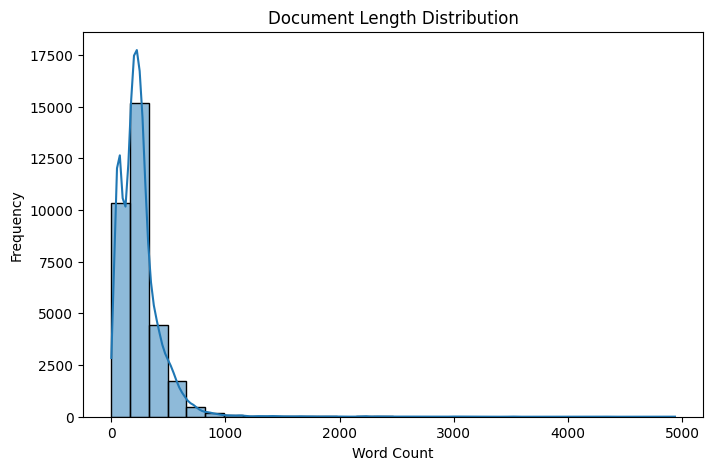

In [16]:

# Plotting document length distribution
plt.figure(figsize=(8, 5))
sns.histplot(df['word_count'], bins=30, kde=True)
plt.title("Document Length Distribution")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.show()


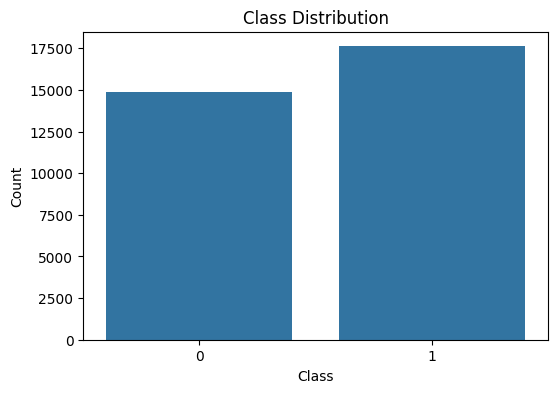

In [17]:
# Plotting class distribution
plt.figure(figsize=(6, 4))
sns.countplot(x=df["binary_label"], data=df)
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

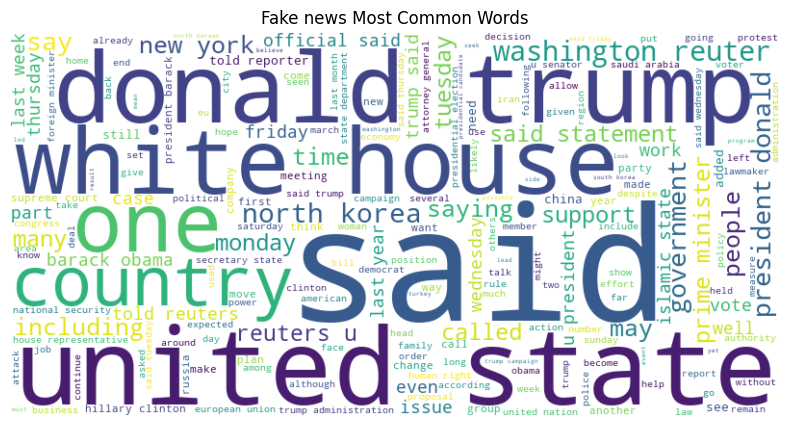

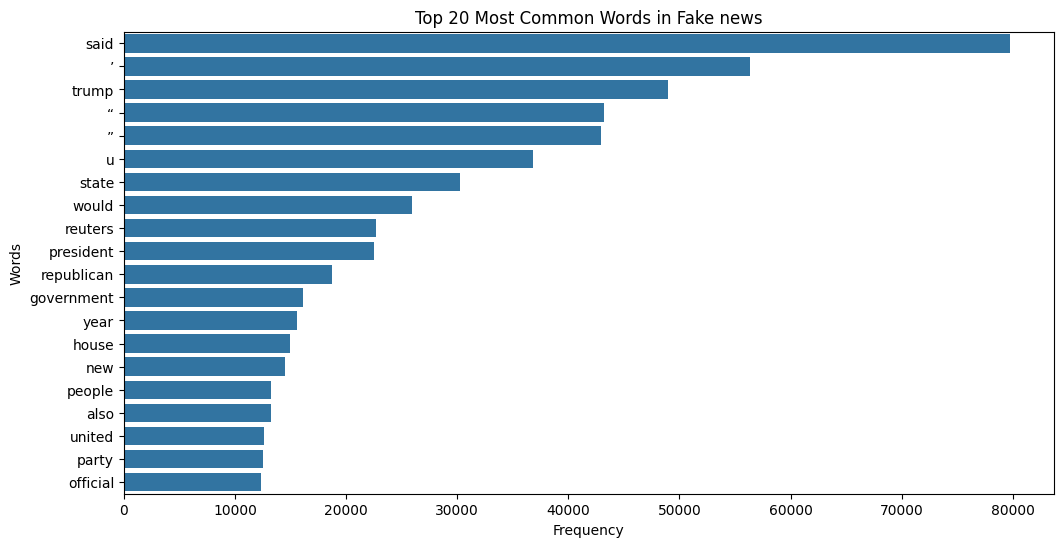

In [18]:
word_freq = Counter(fake_tokens)

# Generate word cloud
wordcloud = WordCloud(width=800, height=400, background_color="white").generate(" ".join(fake_tokens))

# Plot word cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Fake news Most Common Words")
plt.show()

# Display top 20 most common words
top_words = word_freq.most_common(20)
word_df = pd.DataFrame(top_words, columns=["Word", "Frequency"])

# Plot most frequent words
plt.figure(figsize=(12, 6))
sns.barplot(x="Frequency", y="Word", data=word_df)
plt.title("Top 20 Most Common Words in Fake news")
plt.xlabel("Frequency")
plt.ylabel("Words")
plt.show()

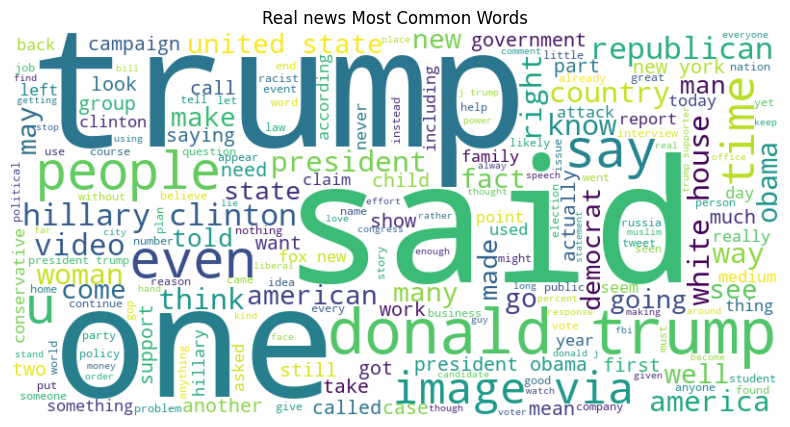

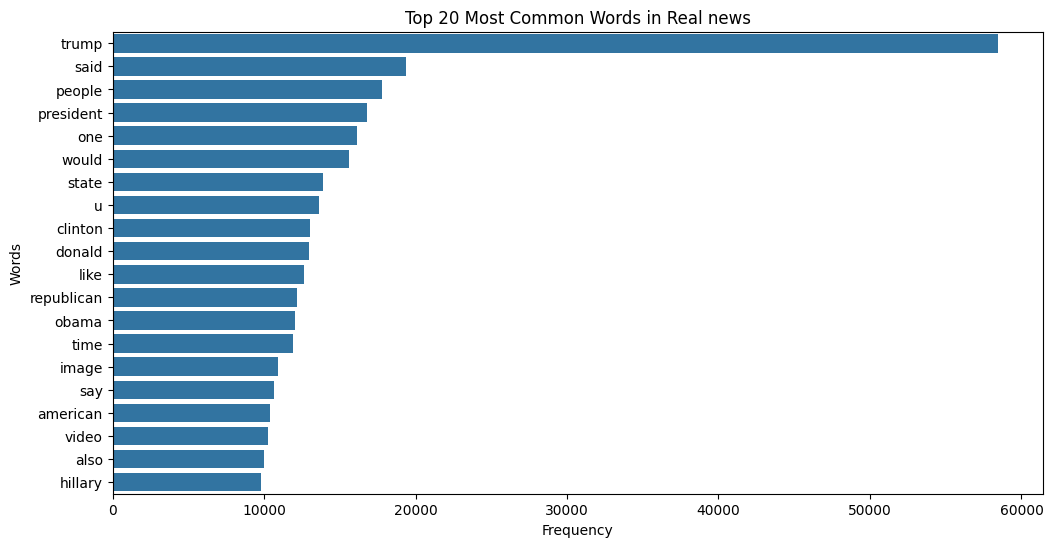

In [19]:
word_freq = Counter(real_tokens)

# Generate word cloud
wordcloud = WordCloud(width=800, height=400, background_color="white").generate(" ".join(real_tokens))

# Plot word cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Real news Most Common Words")
plt.show()

# Display top 20 most common words
top_words = word_freq.most_common(20)
word_df = pd.DataFrame(top_words, columns=["Word", "Frequency"])

# Plot most frequent words
plt.figure(figsize=(12, 6))
sns.barplot(x="Frequency", y="Word", data=word_df)
plt.title("Top 20 Most Common Words in Real news")
plt.xlabel("Frequency")
plt.ylabel("Words")
plt.show()

In [20]:
# manual cleanup
del df
del avg_length
del fake_tokens
del real_tokens
del fake_vocab
del real_vocab
del combined_vocab
del word_freq
del wordcloud
del top_words
del word_df
del class_counts
gc.collect()

603

## 4. Keywords Attention PULP and GAT implementation

### 4.1. Dataset wrapper class

In [21]:
class KAFNData:
    """
    Class wrapping the whole dataset
    """

    def __init__(
        self,
        csv_path,
        random_state=42,
        fraction_fake_labeled=0.3,
        test_size=0.2,
    ):
        """
        Constructor

        Args:
            csv_path (_type_): Path to the CSV file.
            random_state (int, optional): Random seed for reproducible train/test splits. Defaults to 42.
            fraction_fake_labeled (float, optional): Fraction of fake docs (in training set) that will receive a positive label (pu_label=1). Defaults to 0.3.
            test_size (float, optional): Fraction of dataset for the test set. Defaults to 0.2.
        """
        self.fraction_fake_labeled = fraction_fake_labeled
        # Load dataset to memory
        df = pd.read_csv(csv_path, on_bad_lines="skip")

        # Train/test split
        train_df, test_df = train_test_split(
            df,
            test_size=test_size,
            stratify=df["binary_label"],  # preserve class distribution
            random_state=random_state,
        )
        # Combine train/test back into a single df, with a split indicator.
        self.df_all = pd.concat([train_df, test_df], ignore_index=True)
        self.df_all["split"] = "test"
        self.df_all.loc[self.df_all.index[: len(train_df)], "split"] = "train"
        self.num_docs = len(self.df_all)

        # Initialize pu_label => -1 for all docs.
        self.df_all["pu_label"] = -1

        # Find all fake docs in the train set.
        train_fake_inds = self.df_all.index[
            (self.df_all["split"] == "train") & (self.df_all["binary_label"] == 1)
        ].tolist()
        # Number of labeled fake docs to keep.
        n_label = int(fraction_fake_labeled * len(train_fake_inds))
        if n_label < 1 and len(train_fake_inds) > 0:
            n_label = 1

        # Randomly pick that many from the train fake docs to label them as pu_label=1. All of the rest will have label -1, both real and fake.
        if len(train_fake_inds) > 0:
            labeled_inds = np.random.choice(
                train_fake_inds, size=n_label, replace=False
            )
            self.df_all.loc[labeled_inds, "pu_label"] = 1

    def get_doc_text(self, idx):
        """
        Get the whole text data at index
        
        Args:
            idx (_type_): Index

        Returns:
            _type_: Text data
        """
        return self.df_all.iloc[idx]["full_text"]

    def get_pu_label(self, idx):
        """
        Get the PU label (1 => labeled fake, -1 => unlabeled, contains both real and fake).

        Args:
            idx (_type_): Index

        Returns:
            _type_: binary label
        """
        return self.df_all.iloc[idx]["pu_label"]
    def get_binary_label(self, idx):
        """
        Get the original binary label (0 => real, 1 => fake).
        
        Args:
            idx (_type_): _description_

        Returns:
            _type_: _description_
        """
        return self.df_all.iloc[idx]["binary_label"]

    def is_train_doc(self, idx):
        """_summary_

        Args:
            idx (_type_): _description_

        Returns:
            _type_: _description_
        """
        return self.df_all.iloc[idx]["split"] == "train"

    def is_test_doc(self, idx):
        """
        Returns True if doc index belongs to the training set

        Args:
            idx (_type_): Index

        Returns:
            _type_: True if training set
        """
        return self.df_all.iloc[idx]["split"] == "test"

    def get_fraction(self):
        """
        Get fraction of fake docs, that are labeled 1, rest are -1, bot real and fake

        Returns:
            _type_: Fraction of fake docs
        """
        return self.fraction_fake_labeled


### 4.2 Doc2Vec wrapper

In [22]:

class Doc2VecEmb:
    """
    Wrapper for Doc2Vec model for document embeddings.
    """
    def __init__(self, vector_size=100, window=5, min_count=2, epochs=20, workers=8):
        """
        Constructor

        Args:
            vector_size (int, optional): Dimensionality of the embedding vectors. Defaults to 100.
            window (int, optional): Maximum distance between the current and predicted word within a sentence. Defaults to 5.
            min_count (int, optional): Ignores all words with total frequency lower than this. Defaults to 2.
            epochs (int, optional): Number of training epochs. Defaults to 20.
            workers (int, optional): Number of worker threads to train the model.. Defaults to 8.
        """
        self.model = None
        self.vsize = vector_size
        self.window = window
        self.min_count = min_count
        self.epochs = epochs
        self.workers = workers

    def train(self, data: KAFNData):
        """
        Trains the Doc2Vec model on the entire corpus (all docs). Each doc is tokenized, lower-cased, and assigned a unique tag (the doc ID).

        Args:
            data (KAFNData): _description_
        """
        docs = []
        for i in range(data.num_docs):
            tokens = word_tokenize(data.get_doc_text(i).lower())
            docs.append(TaggedDocument(tokens, [i]))

        model = Doc2Vec(
            documents=docs,
            vector_size=self.vsize,
            window=self.window,
            min_count=self.min_count,
            epochs=self.epochs,
            workers=self.workers,
        )
        self.model = model

    def get_vector(self, i):
        """
        Get the learned embedding vector for doc i.

        Args:
            i (_type_): Index

        Returns:
            _type_: embedding vector
        """
        return self.model.dv[i]


### 4.3 TFIDF Wrapper

In [23]:
class TFIDFEmb:
    """
    Wrapper for TF-IDF embeddings
    """
    def __init__(
        self, max_features=10000, ngram_range=(1, 1), min_df=1, stop_words="english"
    ):
        """
        Constructor

        Args:
            max_features (int, optional): Maximum number of features (vocabulary size) in TF-IDF. Defaults to 10000.
            ngram_range (tuple, optional): The lower and upper boundary of the n-grams to be extracted. Defaults to (1, 1).
            min_df (int, optional): Ignore terms that appear in fewer than min_df documents. Defaults to 1.
            stop_words (str, optional): Stop words to remove from the text. Defaults to "english".
        """
        self.vectorizer = TfidfVectorizer(
            max_features=max_features,
            ngram_range=ngram_range,
            min_df=min_df,
            stop_words=stop_words,
        )
        self.doc_vectors = None # store the dense np.array for each doc

    def train(self, data):
        """
        Fit TFIDF on the whole corpus and transform docs into tf-idf vectors. The resulting vectors are converted to dense arrays and stored.

        Args:
            data (_type_): Dataset
        """
        texts = [data.get_doc_text(i) for i in range(data.num_docs)]
        tfidf_matrix = self.vectorizer.fit_transform(texts)
        self.doc_vectors = tfidf_matrix.toarray() # convert to dense np.array 

    def get_vector(self, i):
        """
        Get the tfidf vector for document i

        Args:
            i (_type_): Document index

        Returns:
            _type_: TFIDF vector
        """
        return self.doc_vectors[i]


### 4.4. Build Document Graph

In [24]:
def build_doc_graph(data: KAFNData, emb_model, k=5):
    """
    Build a graph of documents, each doc as a node. Edges connect each doc to its top-k nearest neighbours by cosine similarity.

    Args:
        data (KAFNData): Dataset
        emb_model (Doc2VecEmb or TFIDFEmb): An embedding model
        k (int, optional): Number of neighbors to connect per doc.Defaults to 5.

    Returns:
        nx.Graph: NetworkX graph with doc nodes and weighted edges.
    """
    N = data.num_docs
    # Get embeddings from the embedding model
    all_emb = np.array([emb_model.get_vector(i) for i in range(N)])
    # Compute cosine similarity
    sim = cosine_similarity(all_emb)

    G = nx.Graph()
    # Add nodes for each doc (labeled with node_type="doc")
    for i in range(N):
        G.add_node(i, node_type="doc")

    # For each doc, pick top-k neighbors
    for i in range(N):
        row = sim[i].copy()
        row[i] = -999 # exclude self
        nbrs = np.argsort(row)[::-1][:k] # indices of top-k largest similarities
        for n in nbrs:
            G.add_edge(i, n, weight=sim[i, n])
            G.add_edge(n, i, weight=sim[i, n])

    # Normalize each doc's outgoing edges to sum=1
    for i in range(N):
        neighbors = list(G.neighbors(i))
        total_w = sum(G[i][nb]["weight"] for nb in neighbors)
        if total_w > 0:
            for nb in neighbors:
                old_w = G[i][nb]["weight"]
                G[i][nb]["weight"] = old_w / total_w
    return G


### 4.5 Katz index

In [25]:
def compute_katz_matrix(G, alpha=0.01):
    """
    Compute the Katz similarity matrix for graph G, using the formula: Katz = (I - alpha*A)^(-1) - I, where A is the adjacency matrix.

    Args:
        G (nx.Graph): Graph with N nodes.
        alpha (float, optional): Katz damping factor controlling how much longer paths contribute. Defaults to 0.01.

    Returns:
        np.array:  The Katz similarity matrix, or None if inversion fails.
        dict: Mapping from node ID to row index in the matrix.
    """
    # Sort nodes for consistency
    nodes = sorted(G.nodes())
    N = len(nodes)
    # Build adjacency matrix from the graph weight
    A = np.zeros((N, N), dtype=float)
    idx_map = {n: i for i, n in enumerate(nodes)}
    for u, v, data_e in G.edges(data=True):
        A[idx_map[u], idx_map[v]] = data_e["weight"]

    I = np.eye(N)
    try:
        # Compute Katz matrix
        mat = fractional_matrix_power(I - alpha * A, -1) - I
        return mat, idx_map
    except np.linalg.LinAlgError:
        print("Katz inversion failed.")
        return None, idx_map

### 4.6 Iterative Positive-Unlabeled label propagation

In [26]:
def iterative_pu_lp(katz_mat, idx_map, pos_indices, unl_indices, m_iter=3, lam=1.0):
    """
    Iterative Positive-Unlabeled label propagation.

    Args:
        katz_mat (_type_): NxN Katz similarity matrix
        idx_map (_type_): dictionary mapping doc ID to row index in katz_mat.
        pos_indices (_type_): IDs of docs that are known positives (pu_label=1)
        unl_indices (_type_): IDs of docs that are unlabeled (pu_label=-1)
        m_iter (int, optional): number of PU-LP iterations. Defaults to 3.
        lam (float, optional): The lam (lambda) factor used in iterative PU-LP for controlling set sizes. Defaults to 1.0.

    Returns:
        list: R_I_tot Doc IDs newly assigned to the positive (fake) set.
        list: R_N_tot Doc IDs newly assigned to the negative (real) set.
        list: leftover Doc IDs still unlabeled after the iterations.
    """

    pos_set = set(pos_indices)
    unl_set = set(unl_indices)

    R_I_tot = set()
    R_N_tot = set()

    def mean_sim(u_id, pos_ids):
        """
        Compute the average Katz similarity from doc u_id to all docs in pos_ids.

        Args:
            u_id (_type_): doc u_id
            pos_ids (_type_): positive ids

        Returns:
            _type_: average katz similarity
        """
        if not pos_ids:
            return 0.0
        row_u = idx_map[u_id]
        sims = [katz_mat[row_u, idx_map[p_id]] for p_id in pos_ids]
        return np.mean(sims) if len(sims) > 0 else 0.0

    for _ in range(m_iter):
        subset_size = int((lam / m_iter) * len(pos_set))
        if subset_size < 1 and len(pos_set) > 0:
            subset_size = 1
            
        #Rank unl_set by average sim to pos_set, pick top subset_size => R_I'
        unl_scores = [(u, mean_sim(u, pos_set)) for u in unl_set]
        unl_scores.sort(key=lambda x: x[1], reverse=True)
        R_I_prime = [x[0] for x in unl_scores[:subset_size]]
        for r in R_I_prime:
            unl_set.remove(r)
        R_I_tot.update(R_I_prime)
        pos_set.update(R_I_prime)
        
        # rank the updated unl_set by average sim to pos_set, pick bottom subset_size => R_N'
        unl_scores2 = [(u, mean_sim(u, pos_set)) for u in unl_set]
        unl_scores2.sort(key=lambda x: x[1])
        R_N_prime = [x[0] for x in unl_scores2[:subset_size]]
        for r in R_N_prime:
            unl_set.remove(r)
        R_N_tot.update(R_N_prime)

    return list(R_I_tot), list(R_N_tot), list(unl_set)


### 4.7 Keywords extraction with YAKE

In [27]:
def extract_yake_keywords(text, top_k, yake_lan, yake_n, yake_dedup_lim):
    """
    Extract top_k keywords from a given text using YAKE. Sort them by ascending score (lower is better). Return only the top_k.

    Args:
        text (_type_): Text
        top_k (_type_): Top K words to return after extraction
        yake_lan (_type_): Language used by YAKE
        yake_n (_type_): n-gram size for YAKE keywords (1 => single word).
        yake_dedup_lim (_type_): Deduplication threshold for YAKE.

    Returns:
        _type_: Top K extracted keywords from a text
    """
    extractor = yake.KeywordExtractor(lan=yake_lan, n=yake_n, dedupLim=yake_dedup_lim)
    kw = extractor.extract_keywords(text)
    kw.sort(key=lambda x: x[1])
    return kw[:top_k]

### 4.8 Add extracted keywords into the doc graph

In [28]:

def build_doc_term_edges(
    G_doc,
    data: KAFNData,
    top_k=5,
    yake_lan="en",
    yake_n=1,
    yake_dedup_lim=0.9,
    n_jobs=32,
):
    """
    Incorporate keywords (terms) into the doc graph, forming a doc-term bipartite structure.

    Args:
        G_doc (nx.Graph): Original doc-doc graph.
        data (KAFNData): Dataset
        top_k (int, optional): Number of keywords to extract per doc.. Defaults to 5.
        yake_lan (str, optional): Language for YAKE (e.g. "en", "fr"). Defaults to "en".
        yake_n (int, optional): n-gram size for YAKE keywords (1 => single word). Defaults to 1.
        yake_dedup_lim (float, optional): Deduplication threshold for YAKE. Defaults to 0.9.
        n_jobs (int, optional): Number of parallel jobs (CPU cores) to use in YAKE extraction. Defaults to 32.

    Returns:
        H (nx.Graph): Expanded network containing doc and term nodes, with doc->doc and doc->term edges.
    """
    
    """
    Steps:
      1) Extract top_k keywords for each doc using YAKE in parallel.
      2) Keep only terms appearing in >=2 docs.
      3) Create 'term' nodes for those valid terms.
      4) Create edges doc->term, weighted by YAKE-based normalization.
      5) Normalize again so each node's edges sum to 1.
    """
    N = data.num_docs
    # Create a new graph H that will include both doc and term nodes
    H = nx.Graph()

    #  Copy doc nodes from G_doc and doc->doc edges
    for i in range(N):
        H.add_node(i, node_type="doc")

    for u, v, d in G_doc.edges(data=True):
        H.add_edge(u, v, weight=d["weight"])

    # Extract YAKE keywords (use parallel execution if possible)
    all_texts = [data.get_doc_text(i) for i in range(N)]
    parallel = Parallel(n_jobs=n_jobs, backend="loky")

    all_kw_lists = parallel(
        delayed(extract_yake_keywords)(text, top_k, yake_lan, yake_n, yake_dedup_lim)
        for text in all_texts
    )

    # Summarize term usage
    term_usage = {}
    raw_doc_terms = [[] for _ in range(N)]
    for i, kw in enumerate(all_kw_lists):
        for ts, sc in kw:
            raw_doc_terms[i].append((ts, sc))
            term_usage.setdefault(ts, set()).add(i)
    # Keep only terms used by >=2 docs
    valid_terms = {t for t, used_by in term_usage.items() if len(used_by) >= 2}
    # Create new term nodes
    next_id = N
    term_map = {}
    for t in valid_terms:
        term_map[t] = next_id
        H.add_node(next_id, node_type="term")
        next_id += 1
    # Create doc->term edges with normalized weights
    for i in range(N):
        doc_term_list = []
        for ts, sc in raw_doc_terms[i]:
            if ts not in valid_terms:
                continue
            if sc > 1:
                w_val = 0.0
            else:
                w_val = sc * (1 - (1 / (1 + sc)))
            if w_val > 0:
                doc_term_list.append((ts, w_val))

        # normalize the doc->term edges so their sum=1
        denom = sum(x[1] for x in doc_term_list)
        if denom > 0:
            for ts, w in doc_term_list:
                norm_w = w / denom
                tid = term_map[ts]
                H.add_edge(i, tid, weight=norm_w)
                H.add_edge(tid, i, weight=norm_w)

    # normalize again to be sure each node edges sum to 1, this covers doc->doc and doc->term edges
    for node in H.nodes():
        node_type = H.nodes[node]["node_type"]
        neighbors = list(H.neighbors(node))
        total_w = sum(H[node][nb]["weight"] for nb in neighbors)
        if total_w > 0:
            for nb in neighbors:
                H[node][nb]["weight"] /= total_w

    return H

################################################################################################################
### Utility methods to convert the NX graph into a torch_geometric HeteroData object for easier calculations ###
################################################################################################################

def nx_to_heterodata(H, R_I, R_N, pos_indices, embed_dim=100):
    """
    Convert the doc-term Nx graph into a torch_geometric HeteroData object.

    Args:
        H (_type_): Expanded network containing doc and term nodes, with doc->doc and doc->term edges.
        R_I (_type_): Doc IDs newly assigned to the positive (fake) set.
        R_N (_type_): Doc IDs newly assigned to the negative (real) set.
        pos_indices (_type_): IDs of docs that are known positives (pu_label=1)
        embed_dim (int, optional): Used to allocate vectors for docs and terms as well. Defaults to 100.

    Returns:
        _type_: _description_
    """
    # Separate doc and term nodes
    docs, terms = [], []
    for n, dattr in H.nodes(data=True):
        if dattr["node_type"] == "doc":
            docs.append(n)
        else:
            terms.append(n)
    docs.sort()
    terms.sort()

    # Create doc_label array
    # doc_label: 1 => doc in pos_indices or R_I
    #            0 => doc in R_N
    #            -1 => leftover
    doc_label_arr = []
    pos_set = set(pos_indices)
    R_I_set = set(R_I)
    R_N_set = set(R_N)
    for d in docs:
        if d in pos_set or d in R_I_set:
            doc_label_arr.append(1)
        elif d in R_N_set:
            doc_label_arr.append(0)
        else:
            doc_label_arr.append(-1)
    doc_label_arr = np.array(doc_label_arr)

    doc_map = {d: i for i, d in enumerate(docs)}
    term_map = {t: i for i, t in enumerate(terms)}
    doc_x = np.zeros((len(docs), embed_dim), dtype=np.float32)
    term_x = np.zeros((len(terms), embed_dim), dtype=np.float32)

    doc_doc_src, doc_doc_dst, doc_doc_attr = [], [], []
    doc_term_src, doc_term_dst, doc_term_attr = [], [], []
    term_doc_src, term_doc_dst, term_doc_attr = [], [], []

    for u, v, edat in H.edges(data=True):
        w = edat["weight"]
        ut = H.nodes[u]["node_type"]
        vt = H.nodes[v]["node_type"]
        if ut == "doc" and vt == "doc":
            doc_doc_src.append(doc_map[u])
            doc_doc_dst.append(doc_map[v])
            doc_doc_attr.append(w)
        elif ut == "doc" and vt == "term":
            doc_term_src.append(doc_map[u])
            doc_term_dst.append(term_map[v])
            doc_term_attr.append(w)
        elif ut == "term" and vt == "doc":
            term_doc_src.append(term_map[u])
            term_doc_dst.append(doc_map[v])
            term_doc_attr.append(w)

    # doc node feature matrix, label array, original doc IDs
    hetero_data = HeteroData()
    hetero_data["doc"].x = torch.FloatTensor(doc_x)
    hetero_data["doc"].labels = torch.LongTensor(doc_label_arr)
    hetero_data["doc"].docs = torch.LongTensor(docs)

    # term node feature matrix
    hetero_data["term"].x = torch.FloatTensor(term_x)

    # doc->doc edges
    hetero_data["doc", "to", "doc"].edge_index = torch.tensor(
        [doc_doc_src, doc_doc_dst], dtype=torch.long
    )
    hetero_data["doc", "to", "doc"].edge_attr = torch.FloatTensor(doc_doc_attr)

    # doc->term edges
    hetero_data["doc", "to", "term"].edge_index = torch.tensor(
        [doc_term_src, doc_term_dst], dtype=torch.long
    )
    hetero_data["doc", "to", "term"].edge_attr = torch.FloatTensor(doc_term_attr)

    # term->doc edges
    hetero_data["term", "to", "doc"].edge_index = torch.tensor(
        [term_doc_src, term_doc_dst], dtype=torch.long
    )
    hetero_data["term", "to", "doc"].edge_attr = torch.FloatTensor(term_doc_attr)

    return hetero_data, docs, terms


def fill_doc_embeddings(hetero_data: HeteroData, docs, data: KAFNData, emb_model):
    """
    Fill hetero_data["doc"].x with the actual document embeddings computed by the emb_model (Doc2Vec or TF-IDF).

    Args:
        hetero_data (HeteroData): The PyG heterogeneous data object.
        docs (list): The sorted list of doc IDs.
        data (KAFNData): Dataset object
        emb_model (Doc2VecEmb or TFIDFEmb): The embedding model.
    """
    doc_x_list = []
    for d in docs:
        emb = emb_model.get_vector(d)
        doc_x_list.append(emb)
    doc_x_arr = np.vstack(doc_x_list).astype(np.float32)
    hetero_data["doc"].x = torch.tensor(doc_x_arr)



### 4.9 Multi-head, multi-layer Hetero GAT (Graph Attention Network)  

In [29]:
class HeteroGAT(nn.Module):
    """
    A multi-layer GAT architecture for heterogeneous data, focusing on doc->doc, doc->term, term->doc edges.
    """

    def __init__(self, in_dim, hidden_dim=64, num_layers=2, num_heads=4, dropout=0.5):
        """
        Constructor

        Args:
            in_dim (int): Dimension of input features (doc.x dimension).
            hidden_dim (int, optional): Dimension of each head's output in GATConv (before concatenation). Defaults to 64.
            num_layers (int, optional): Number of GAT layers to stack. Layers of HeteroConv, each containing GATConv for doc->doc, doc->term, and term->doc. Defaults to 2
            num_heads (int, optional): Number of attention heads in each GATConv. By default, PyG's GATConv concatenates attention heads. Defaults to 4.
            dropout (float, optional): Dropout probability applied after each layer. Defaults to 0.5.
        """
        super().__init__()

        self.num_layers = num_layers
        self.dropout = dropout

        # Layer 1: HeteroConv with doc->doc, doc->term, term->doc GATConv
        self.conv1 = HeteroConv(
            {
                ("doc", "to", "doc"): GATConv(
                    in_dim,
                    hidden_dim,
                    heads=num_heads,
                    add_self_loops=False,
                    concat=True,
                ),
                ("doc", "to", "term"): GATConv(
                    in_dim,
                    hidden_dim,
                    heads=num_heads,
                    add_self_loops=False,
                    concat=True,
                ),
                ("term", "to", "doc"): GATConv(
                    in_dim,
                    hidden_dim,
                    heads=num_heads,
                    add_self_loops=False,
                    concat=True,
                ),
            },
            aggr="sum",
        )

        # Optional layer 2
        self.conv2 = None
        if num_layers >= 2:
            self.conv2 = HeteroConv(
                {
                    ("doc", "to", "doc"): GATConv(
                        hidden_dim * num_heads,
                        hidden_dim,
                        heads=num_heads,
                        add_self_loops=False,
                        concat=True,
                    ),
                    ("doc", "to", "term"): GATConv(
                        hidden_dim * num_heads,
                        hidden_dim,
                        heads=num_heads,
                        add_self_loops=False,
                        concat=True,
                    ),
                    ("term", "to", "doc"): GATConv(
                        hidden_dim * num_heads,
                        hidden_dim,
                        heads=num_heads,
                        add_self_loops=False,
                        concat=True,
                    ),
                },
                aggr="sum",
            )

        # Final linear classifier from the doc node's last-layer representation -> 1 logit per doc node (binary classification).
        final_dim = hidden_dim * num_heads if self.conv2 else hidden_dim * num_heads
        self.classify = nn.Linear(final_dim, 1)

    def forward(self, data: HeteroData):
        """
        Forward pass through 1 or 2 GAT layers, then classification.

        Args:
            data (HeteroData): The PyG heterogeneous data object.

        Returns:
            out_dict(dict): Dictionary with node features after the final GAT layer (by node type).
            doc_logits(torch.Tensor): The predicted logits for doc nodes
        """
        x_dict, edge_index_dict, edge_attr_dict = (
            data.x_dict,
            data.edge_index_dict,
            data.edge_attr_dict,
        )

        # Layer 1
        out1 = self.conv1(x_dict, edge_index_dict, edge_attr_dict)
        for nt in out1:
            out1[nt] = F.elu(out1[nt]) # activation
            out1[nt] = F.dropout(out1[nt], p=self.dropout, training=self.training)

        # If only 1 layer classification is from out1 only
        if self.conv2 is not None:
            # Layer 2
            out2 = self.conv2(out1, edge_index_dict, edge_attr_dict)
            for nt in out2:
                out2[nt] = F.elu(out2[nt])
                out2[nt] = F.dropout(out2[nt], p=self.dropout, training=self.training)
            doc_logits = self.classify(out2["doc"]).squeeze(-1)
            return out2, doc_logits
        else:
            doc_logits = self.classify(out1["doc"]).squeeze(-1)
            return out1, doc_logits

## 5. Full pipeline implementation

### 5.1. Evaluation metrics

In [30]:
def evaluation_metrics(
    y_true, y_pred, y_proba=None, title=None, labels=["real", "fake"], file_name=None
):
    """
    Prints out confusion metrix and classification metrics. If file_name is specified - saves output to file.

    Args:
        y_true (_type_): True labels for test set (0 => real, 1 => fake).
        y_pred (_type_): Predicted labels (0 => real, 1 => fake).
        y_proba (_type_, optional): Predicted probabilities for the positive class. Used to compute ROC-AUC and PR-AUC. Defaults to None.
        title (_type_, optional): Title to display with the metrics. Defaults to None.
        labels (list, optional): Class labels. Defaults to ["real", "fake"].
    """
    print(f"\n{title}")
    print(classification_report(y_true, y_pred, target_names=labels, digits=4))

    # Display confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot()
    plt.title(title)
    plt.show()

    # If probabilities are given, also show ROC-AUC and PR-AUC
    if y_proba is not None:
        roc_auc = roc_auc_score(y_true, y_proba)
        pr_auc = average_precision_score(y_true, y_proba)
        print(f"ROC-AUC: {roc_auc:.4f}")
        print(f"PR-AUC: {pr_auc:.4f}")
    print("\n")

    # Save to file if file_name is provided
    if file_name:
        report_dict = classification_report(
            y_true, y_pred, target_names=labels, output_dict=True
        )
        if y_proba is not None:
            roc_auc = roc_auc_score(y_true, y_proba)
            pr_auc = average_precision_score(y_true, y_proba)
        df_report = pd.DataFrame(report_dict).transpose()
        if y_proba is not None:
            df_report["roc_auc"] = roc_auc
            df_report["pr_auc"] = pr_auc
        df_report.to_csv(file_name, index=True)


def clear_gpu_cache():
    """Clears GPU cache"""
    with torch.no_grad():
        torch.cuda.empty_cache()

### 5.2. Baseline Model (MultinomialNB with TF-IDF)

In [31]:
def baseline(data: KAFNData):
    """
    Simple baseline using TF-IDF and MultinomialNB. Used on the entire training set with pseudo-labels:
    pu_label == 1 => positive (fake)
    pu_label == -1 => negative (real or unlabeled fake)
    
    Args:
        data (KAFNData): Dataset
    """
    # Prepare data for baseline based on split column
    train_df = data.df_all[data.df_all["split"] == "train"]
    X_tr = train_df["full_text"]
    y_tr = train_df["pu_label"].apply(lambda x: 1 if x == 1 else 0)

    # X_tr => training texts, y_tr => pseudo-labels (1 => labeled fake, 0 => otherwise)
    test_df = data.df_all[data.df_all["split"] == "test"]
    X_tst = test_df["full_text"]
    y_tst = test_df["binary_label"]

    # Init pipeline TF-IDF => MultinomialNB
    pipeline = Pipeline(
        [
            (
                "tfidf",
                TfidfVectorizer(
                    stop_words="english",
                    max_features=5000, # features
                    ngram_range=(1, 2), # unigrams + bigrams
                ),
            ),
            (
                "classifier",
                MultinomialNB(class_prior=[0.5, 0.5]), # prior class probabilities
            ),
        ]
    )
    # Train
    pipeline.fit(X_tr, y_tr)
    
    # Predict
    y_pr = pipeline.predict(X_tst)
    proba = pipeline.predict_proba(X_tst)
    y_proba = proba[:, 1] if proba.shape[1] > 1 else proba[:, 0]

    title = f"=== Baseline with TfidfVectorizer and MultinomialNB, Labeled fraction {data.fraction_fake_labeled} ==="
    
    # Print and save metrics to file
    evaluation_metrics(
        y_tst,
        y_pr,
        y_proba,
        title=title,
        file_name=f"result/baseline_{data.fraction_fake_labeled}.csv",
    )
    

### 5.3 Keywords attention PULP with Doc2Vec embeddings

In [32]:
def kafn_pulp_pipeline(
    data: KAFNData,
    # Doc2Vec params
    embed_dim=100,
    doc2vec_window=5,
    doc2vec_min_count=2,
    doc2vec_epochs=20,
    doc2vec_workers=os.cpu_count(),
    # Graph / Label Propagation
    k=5,
    alpha_katz=0.01,
    m_iter=3,
    m_factor=1.0,
    # YAKE params
    top_yake=5,
    yake_lan="en",
    yake_n=1,
    yake_dedup_lim=0.9,
    n_jobs=os.cpu_count(),
    # Multi-layer, multi-head GAT params
    gat_hidden_dim=64,
    gat_num_layers=2,
    gat_num_heads=4,
    gat_dropout=0.5,
    # Training parameters
    num_epochs=30,
    lr=1e-3,
    weight_decay=1e-4,
    device="cpu",
):
    """
    Full pipeline that:
      1) Trains Doc2Vec on the entire corpus.
      2) Builds a doc->doc similarity graph using top-k neighbors.
      3) Computes Katz matrix for global similarity, runs iterative PU label propagation.
      4) Extracts keywords via YAKE, adds doc->term edges, normalizes everything.
      5) Converts Nx to PyG HeteroData.
      6) Fills doc embeddings from the trained Doc2Vec model.
      7) Constructs and trains a multi-layer multi-head HeteroGAT.
      8) Evaluates using the real labels.

    Args:
        data (KAFNData): Data wrapper containing both train and test sets, including partial labels for train.
        embed_dim (int, optional): Size of the Doc2Vec embeddings. Defaults to 100.
        doc2vec_window (int, optional): Window size for Doc2Vec model. Defaults to 5.
        doc2vec_min_count (int, optional): Minimum frequency for words in Doc2Vec training. Defaults to 2.
        doc2vec_epochs (int, optional): Epochs to train the Doc2Vec model. Defaults to 20.
        doc2vec_workers (_type_, optional): Number of worker threads for Doc2Vec training. Defaults to os.cpu_count().
        k (int, optional): Number of neighbors in doc->doc graph. Defaults to 5.
        alpha_katz (float, optional): Katz alpha controlling damping factor. Defaults to 0.01.
        m_iter (int, optional): Number of iterations for iterative PU-LP. Defaults to 3.
        m_factor (float, optional): The lambda factor used in iterative PU-LP for controlling set sizes. Defaults to 1.0.
        top_yake (int, optional): Number of keywords to extract per doc via YAKE. Defaults to 5.
        yake_lan (str, optional): Language code for YAKE ("en", "fr", etc.). Defaults to "en".
        yake_n (int, optional): n-gram size for YAKE keyword extraction. Defaults to 1.
        yake_dedup_lim (float, optional): Deduplication threshold in YAKE. Defaults to 0.9.
        n_jobs (_type_, optional): Parallelization for YAKE extraction. Defaults to os.cpu_count().
        gat_hidden_dim (int, optional): Dimension for GAT hidden layers (per head). Defaults to 64.
        gat_num_layers (int, optional): How many GAT layers to stack. Defaults to 2.
        gat_num_heads (int, optional): Number of attention heads in each GAT layer. Defaults to 4.
        gat_dropout (float, optional): Dropout probability used in GAT layers. Defaults to 0.5.
        num_epochs (int, optional): Number of training epochs for the GAT model. Defaults to 30.
        lr (_type_, optional): Learning rate for optimizer. Defaults to 1e-3.
        weight_decay (_type_, optional): L2 regularization factor. Defaults to 1e-4.
        device (str, optional): "cpu" or "cuda". If "cuda" is available, GPU is used. Defaults to "cpu". "mps" not supported.
    """
    print("=== Training Doc2Vec ===")
    emb_model = Doc2VecEmb(
        vector_size=embed_dim,
        window=doc2vec_window,
        min_count=doc2vec_min_count,
        epochs=doc2vec_epochs,
        workers=doc2vec_workers,
    )
    emb_model.train(data)

    print("=== Building doc-doc graph ===")
    G_doc = build_doc_graph(data, emb_model, k=k)

    print("=== Computing Katz matrix ===")
    katz_mat, idx_map = compute_katz_matrix(G_doc, alpha=alpha_katz)
    if katz_mat is None:
        print("Katz failed, aborting.")
        return
    pos_indices = [i for i in range(data.num_docs) if data.get_pu_label(i) == 1]
    unl_indices = [i for i in range(data.num_docs) if data.get_pu_label(i) == -1]

    print("=== Iterative PU Label Propagation ===")
    R_I, R_N, leftover = iterative_pu_lp(
        katz_mat, idx_map, pos_indices, unl_indices, m_iter=m_iter, lam=m_factor
    )
    R_I = set(R_I)
    R_N = set(R_N)
    print(f"  => Found R_I={len(R_I)}, R_N={len(R_N)}, leftover={len(leftover)}")

    print("=== Building doc-term edges ===")
    H_all = build_doc_term_edges(
        G_doc,
        data,
        top_k=top_yake,
        yake_lan=yake_lan,
        yake_n=yake_n,
        yake_dedup_lim=yake_dedup_lim,
        n_jobs=n_jobs,
    )

    print("=== Converting Nx -> HeteroData ===")
    hetero_data, doc_ids, term_ids = nx_to_heterodata(
        H_all, R_I, R_N, pos_indices, embed_dim=embed_dim
    )

    print("=== Filling doc embeddings ===")
    fill_doc_embeddings(hetero_data, doc_ids, data, emb_model)

    # Move data to chosen device (CPU or GPU). mps not supported
    device_ = torch.device(
        device if torch.cuda.is_available() or device == "cpu" else "cpu"
    )
    hetero_data = hetero_data.to(device_)

    print("=== Building Multi-Layer HeteroGAT model ===")
    in_dim = hetero_data["doc"].x.size(1)
    model = HeteroGAT(
        in_dim=in_dim,
        hidden_dim=gat_hidden_dim,
        num_layers=gat_num_layers,
        num_heads=gat_num_heads,
        dropout=gat_dropout,
    ).to(device_)

    optimizer = Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.BCEWithLogitsLoss()

    # only compute loss on doc nodes that have label >=0
    doc_labels = hetero_data["doc"].labels  # [num_docs]
    labeled_mask = doc_labels >= 0
    labeled_y = doc_labels[labeled_mask].float().to(device_)

    best_f1 = 0.0
    metrics_history = []

    for epoch in range(num_epochs):
        model.train()
        optimizer.zero_grad()

        # Forward pass
        _, doc_logits = model(hetero_data)
        doc_logits_labeled = doc_logits[labeled_mask]
        loss = criterion(doc_logits_labeled, labeled_y)
        loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            _, doc_logits_eval = model(hetero_data)
            preds_eval = (doc_logits_eval.sigmoid() > 0.5).long().cpu().numpy()

        # Extract test docs
        test_docs = []
        test_true = []
        test_pred = []
        for i, did in enumerate(doc_ids):
            if data.is_test_doc(did):
                test_docs.append(did)
                test_true.append(data.get_binary_label(did))
                test_pred.append(preds_eval[i])

        c_report = classification_report(
            test_true,
            test_pred,
            labels=[0, 1],
            target_names=["real", "fake"],
            output_dict=True,
        )
        # Track F1 for the fake news class
        f1_fake = c_report["fake"]["f1-score"]
        acc = c_report["accuracy"]
        metrics_history.append(
            {
                "epoch": epoch + 1,
                "loss": loss.item(),
                "f1_fake": f1_fake,
                "accuracy": acc,
            }
        )

        model_name = f"model/kafn_pulp_doc2vec_{data.get_fraction()}.pth"
        os.makedirs(os.path.dirname(model_name), exist_ok=True)
        # If new best F1, save model
        if f1_fake > best_f1:
            best_f1 = f1_fake
            torch.save(model.state_dict(), model_name)

        # Print some feedback every few epochs
        if (epoch + 1) % 5 == 0:
            print(
                f"Epoch {epoch+1}/{num_epochs} | Loss={loss.item():.4f} | F1_fake={f1_fake:.4f}"
            )

    # After training, save the metrics to CSV
    result_name = f"result/kafn_pulp_doc2vec_{data.get_fraction()}.csv"
    os.makedirs(os.path.dirname(result_name), exist_ok=True)
    df_metrics = pd.DataFrame(metrics_history)
    df_metrics.to_csv(result_name, index=False)

    # Final check with best model
    model.load_state_dict(torch.load(model_name))
    model.eval()
    with torch.no_grad():
        _, doc_logits_eval = model(hetero_data)
        preds_eval = (doc_logits_eval.sigmoid() > 0.5).long().cpu().numpy()

    test_docs, test_true, test_pred = [], [], []
    for i, did in enumerate(doc_ids):
        if data.is_test_doc(did):
            test_docs.append(did)
            test_true.append(data.get_binary_label(did))
            test_pred.append(preds_eval[i])

    title = f"\n=== Keywords attention PU-LP with Doc2Vec, Labeled fraction {data.fraction_fake_labeled} ==="
    evaluation_metrics(test_true, test_pred, title=title)

### 5.4 Keywords attention PULP with TF-IDF embeddings

In [33]:
def kafn_pulp_pipeline_tfidf(
    data: KAFNData,
    # TF-IDF parameters
    max_features=10000,
    ngram_range=(1, 1),
    min_df=2,
    stop_words="english",
    # Graph / Label Propagation
    k=5,
    alpha_katz=0.01,
    m_iter=3,
    m_factor=1.0,
    # YAKE params
    top_yake=5,
    yake_lan="en",
    yake_n=1,
    yake_dedup_lim=0.9,
    n_jobs=os.cpu_count(),
    # Multi-layer, multi-head GAT params
    gat_hidden_dim=64,
    gat_num_layers=2,
    gat_num_heads=4,
    gat_dropout=0.5,
    # Training parameters
    num_epochs=30,
    lr=1e-3,
    weight_decay=1e-4,
    device="cpu",
):
    """
    Full pipeline that:
      1) Uses TF-IDF on the entire corpus.
      2) Builds a doc->doc similarity graph using top-k neighbors.
      3) Computes Katz matrix for global similarity, runs iterative PU label propagation.
      4) Extracts keywords via YAKE, adds doc->term edges, normalizes everything.
      5) Converts Nx to PyG HeteroData.
      6) Fills doc embeddings from the trained Doc2Vec model.
      7) Constructs and trains a multi-layer multi-head HeteroGAT.
      8) Evaluates using the real labels.

    Args:
        data (KAFNData): _description_
        max_features (int, optional): Maximum number of features (vocabulary size) in TF-IDF. Defaults to 10000.
        ngram_range (tuple, optional): The lower and upper boundary of the n-grams to be extracted. Defaults to (1, 1).
        min_df (int, optional): Ignore terms that appear in fewer than min_df documents. Defaults to 2.
        stop_words (str, optional): Stop words to remove from the text. Defaults to "english".
        k (int, optional): Number of neighbors in doc->doc graph. Defaults to 5.
        alpha_katz (float, optional): Katz alpha controlling damping factor. Defaults to 0.01.
        m_iter (int, optional): Number of iterations for iterative PU-LP. Defaults to 3.
        m_factor (float, optional): The lambda factor used in iterative PU-LP for controlling set sizes. Defaults to 1.0.
        top_yake (int, optional): Number of keywords to extract per doc via YAKE. Defaults to 5.
        yake_lan (str, optional): Language code for YAKE ("en", "fr", etc.). Defaults to "en".
        yake_n (int, optional): n-gram size for YAKE keyword extraction. Defaults to 1.
        yake_dedup_lim (float, optional): Deduplication threshold in YAKE. Defaults to 0.9.
        n_jobs (_type_, optional): Parallelization for YAKE extraction. Defaults to os.cpu_count().
        gat_hidden_dim (int, optional): Dimension for GAT hidden layers (per head). Defaults to 64.
        gat_num_layers (int, optional): How many GAT layers to stack. Defaults to 2.
        gat_num_heads (int, optional): Number of attention heads in each GAT layer. Defaults to 4.
        gat_dropout (float, optional): Dropout probability used in GAT layers. Defaults to 0.5.
        num_epochs (int, optional): Number of training epochs for the GAT model. Defaults to 30.
        lr (_type_, optional): Learning rate for optimizer. Defaults to 1e-3.
        weight_decay (_type_, optional): L2 regularization factor. Defaults to 1e-4.
        device (str, optional): "cpu" or "cuda". If "cuda" is available, GPU is used. Defaults to "cpu". "mps" not supported.
    """
    print("=== Computing TF-IDF ===")
    tfidf_model = TFIDFEmb(
        max_features=max_features,
        ngram_range=ngram_range,
        min_df=min_df,
        stop_words=stop_words,
    )
    tfidf_model.train(data)

    print("=== Building doc-doc graph ===")
    G_doc = build_doc_graph(data, tfidf_model, k=k)

    print("=== Computing Katz matrix ===")
    katz_mat, idx_map = compute_katz_matrix(G_doc, alpha=alpha_katz)
    if katz_mat is None:
        print("Katz failed, aborting.")
        return

    pos_indices = [i for i in range(data.num_docs) if data.get_pu_label(i) == 1]
    unl_indices = [i for i in range(data.num_docs) if data.get_pu_label(i) == -1]

    print("=== Iterative PU Label Propagation ===")
    R_I, R_N, leftover = iterative_pu_lp(
        katz_mat, idx_map, pos_indices, unl_indices, m_iter=m_iter, lam=m_factor
    )
    R_I = set(R_I)
    R_N = set(R_N)
    print(f"  => Found R_I={len(R_I)}, R_N={len(R_N)}, leftover={len(leftover)}")

    print("=== Building doc-term edges ===")
    H_all = build_doc_term_edges(
        G_doc,
        data,
        top_k=top_yake,
        yake_lan=yake_lan,
        yake_n=yake_n,
        yake_dedup_lim=yake_dedup_lim,
        n_jobs=n_jobs,
    )

    print("=== Converting Nx -> HeteroData ===")
    hetero_data, doc_ids, term_ids = nx_to_heterodata(
        H_all,
        R_I,
        R_N,
        pos_indices,
        embed_dim=tfidf_model.doc_vectors.shape[1],
    )

    print("=== Filling doc embeddings ===")
    doc_x_list = []
    for d in doc_ids:
        emb = tfidf_model.get_vector(d)
        doc_x_list.append(emb)
    doc_x_arr = np.vstack(doc_x_list).astype(np.float32)
    hetero_data["doc"].x = torch.tensor(doc_x_arr)
    device_ = torch.device(
        device if torch.cuda.is_available() or device == "cpu" else "cpu"
    )
    hetero_data = hetero_data.to(device_)

    print("=== Building Multi-Layer HeteroGAT model ===")
    in_dim = hetero_data["doc"].x.size(1)
    model = HeteroGAT(
        in_dim=in_dim,
        hidden_dim=gat_hidden_dim,
        num_layers=gat_num_layers,
        num_heads=gat_num_heads,
        dropout=gat_dropout,
    ).to(device_)

    optimizer = Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.BCEWithLogitsLoss()

    doc_labels = hetero_data["doc"].labels
    labeled_mask = doc_labels >= 0
    labeled_y = doc_labels[labeled_mask].float().to(device_)

    print("=== Training ===")
    best_f1 = 0.0
    metrics_history = []

    for epoch in range(num_epochs):
        model.train()
        optimizer.zero_grad()

        # Forward pass
        _, doc_logits = model(hetero_data)
        doc_logits_labeled = doc_logits[labeled_mask]
        loss = criterion(doc_logits_labeled, labeled_y)
        loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            _, doc_logits_eval = model(hetero_data)
            preds_eval = (doc_logits_eval.sigmoid() > 0.5).long().cpu().numpy()

        # Extract test docs
        test_docs = []
        test_true = []
        test_pred = []
        for i, did in enumerate(doc_ids):
            if data.is_test_doc(did):
                test_docs.append(did)
                test_true.append(data.get_binary_label(did))
                test_pred.append(preds_eval[i])

        c_report = classification_report(
            test_true,
            test_pred,
            labels=[0, 1],
            target_names=["real", "fake"],
            output_dict=True,
        )
        f1_fake = c_report["fake"]["f1-score"]
        acc = c_report["accuracy"]

        metrics_history.append(
            {
                "epoch": epoch + 1,
                "loss": loss.item(),
                "f1_fake": f1_fake,
                "accuracy": acc,
            }
        )

        model_name = f"model/kafn_pulp_tfidf_{data.get_fraction()}.pth"
        os.makedirs(os.path.dirname(model_name), exist_ok=True)
        # If new best F1, save model
        if f1_fake > best_f1:
            best_f1 = f1_fake
            torch.save(model.state_dict(), model_name)

        # Print some feedback every few epochs
        if (epoch + 1) % 5 == 0:
            print(
                f"Epoch {epoch+1}/{num_epochs} | Loss={loss.item():.4f} | F1_fake={f1_fake:.4f}"
            )

    # After training, dump the metrics to CSV
    result_name = f"result/kafn_pulp_tfidf_{data.get_fraction()}.csv"
    os.makedirs(os.path.dirname(result_name), exist_ok=True)
    df_metrics = pd.DataFrame(metrics_history)
    df_metrics.to_csv(result_name, index=False)

    # Final check with best model
    model.load_state_dict(torch.load(model_name))
    model.eval()
    with torch.no_grad():
        _, doc_logits_eval = model(hetero_data)
        preds_eval = (doc_logits_eval.sigmoid() > 0.5).long().cpu().numpy()

    test_docs, test_true, test_pred = [], [], []
    for i, did in enumerate(doc_ids):
        if data.is_test_doc(did):
            test_docs.append(did)
            test_true.append(data.get_binary_label(did))
            test_pred.append(preds_eval[i])

    title = f"\n=== Keywords attention PU-LP with TFIDF, Labeled fraction {data.fraction_fake_labeled} ==="
    evaluation_metrics(test_true, test_pred, title=title)

### 5.5 SGD Classifier used as an SVM (with hinge loss)

In [34]:
def sgd(data: KAFNData, n_jobs=-1):
    """
    Model using TFIDF and SGD Classifier (linear classifier). This is an approximate SVM trained with SGD (Stochastic Gradient Descent)

    Args:
        data (KAFNData): data
        n_jobs (int, optional): Number of jobs for paralel. Defaults to -1.
    """
    train_df = data.df_all[data.df_all["split"] == "train"]
    X_tr = train_df["full_text"]
    y_tr = train_df["pu_label"].apply(lambda x: 1 if x == 1 else 0)
    test_df = data.df_all[data.df_all["split"] == "test"]
    X_tst = test_df["full_text"]
    y_tst = test_df["binary_label"]

    pipeline = Pipeline(
        [
            (
                "tfidf",
                TfidfVectorizer(
                    stop_words="english", max_features=5000, ngram_range=(1, 2)
                ),
            ),
            (
                "classifier",
                SGDClassifier(
                    loss="hinge",
                    class_weight="balanced",
                    n_jobs=n_jobs,
                    random_state=42,
                ),
            ),
        ]
    )
    pipeline.fit(X_tr, y_tr)
    y_pr = pipeline.predict(X_tst)

    title = f"=== TF-IDF and SGDClassifier (Linear SVM), Labeled fraction {data.fraction_fake_labeled} ==="
    evaluation_metrics(
        y_tst,
        y_pr,
        title=title,
        file_name=f"result/sgd_{data.fraction_fake_labeled}.csv",
    )

## 6. Tests

The following hyperparameters are for testing. For more verbose explanaiton of the hyperparameter, please refer to the pipline documentation above.

In [35]:
def test_baseline(data: KAFNData):
    baseline(data)
    clear_gpu_cache()


def test_pulp_doc2vec_pipeline(data: KAFNData):
    kafn_pulp_pipeline(
        data,
        embed_dim=100,
        doc2vec_window=5,
        doc2vec_min_count=2,
        doc2vec_epochs=30,
        doc2vec_workers=os.cpu_count(),
        k=5,
        alpha_katz=0.02,
        m_iter=3,
        m_factor=1.0,
        top_yake=5,
        yake_lan="en",
        yake_n=1,
        yake_dedup_lim=0.9,
        n_jobs=os.cpu_count(),
        gat_hidden_dim=64,
        gat_num_layers=2,
        gat_num_heads=2,
        gat_dropout=0.5,
        num_epochs=100,
        lr=1e-3,
        weight_decay=1e-4,
        device="cuda",
    )
    clear_gpu_cache()


def test_pulp_tfidfvectorizer_pipeline(data: KAFNData):
    kafn_pulp_pipeline_tfidf(
        data,
        max_features=5000,
        ngram_range=(1, 3),
        min_df=2,
        stop_words="english",
        k=5,
        alpha_katz=0.02,
        m_iter=3,
        m_factor=1.0,
        top_yake=5,
        yake_lan="en",
        yake_n=1,
        yake_dedup_lim=0.9,
        n_jobs=os.cpu_count(),
        gat_hidden_dim=64,
        gat_num_layers=2,
        gat_num_heads=4,
        gat_dropout=0.5,
        num_epochs=100,
        lr=1e-3,
        weight_decay=1e-4,
        device="cuda",
    )
    clear_gpu_cache()


def test_sgdclassifier(data: KAFNData):
    sgd(data)
    clear_gpu_cache()

Test on 0.4, 0.35, 0.3, 0.25, 0.2, 0.15, 0.1 fractions of labeled fake news articles.

In [36]:
dataset_file = "data/processed.csv"
fraction = [0.4, 0.35, 0.3, 0.25, 0.2, 0.15, 0.1]


In [37]:
# Test for all fractions
for frac in fraction:
    data = KAFNData(
        csv_path=dataset_file, random_state=42, fraction_fake_labeled=frac, test_size=0.2
    )
    # test_baseline(data)
    # test_pulp_doc2vec_pipeline(data)
    # test_pulp_tfidfvectorizer_pipeline(data)
    # test_sgdclassifier(data)
    del data
    gc.collect()

## 7. Results

### 7.1 Visualising Results

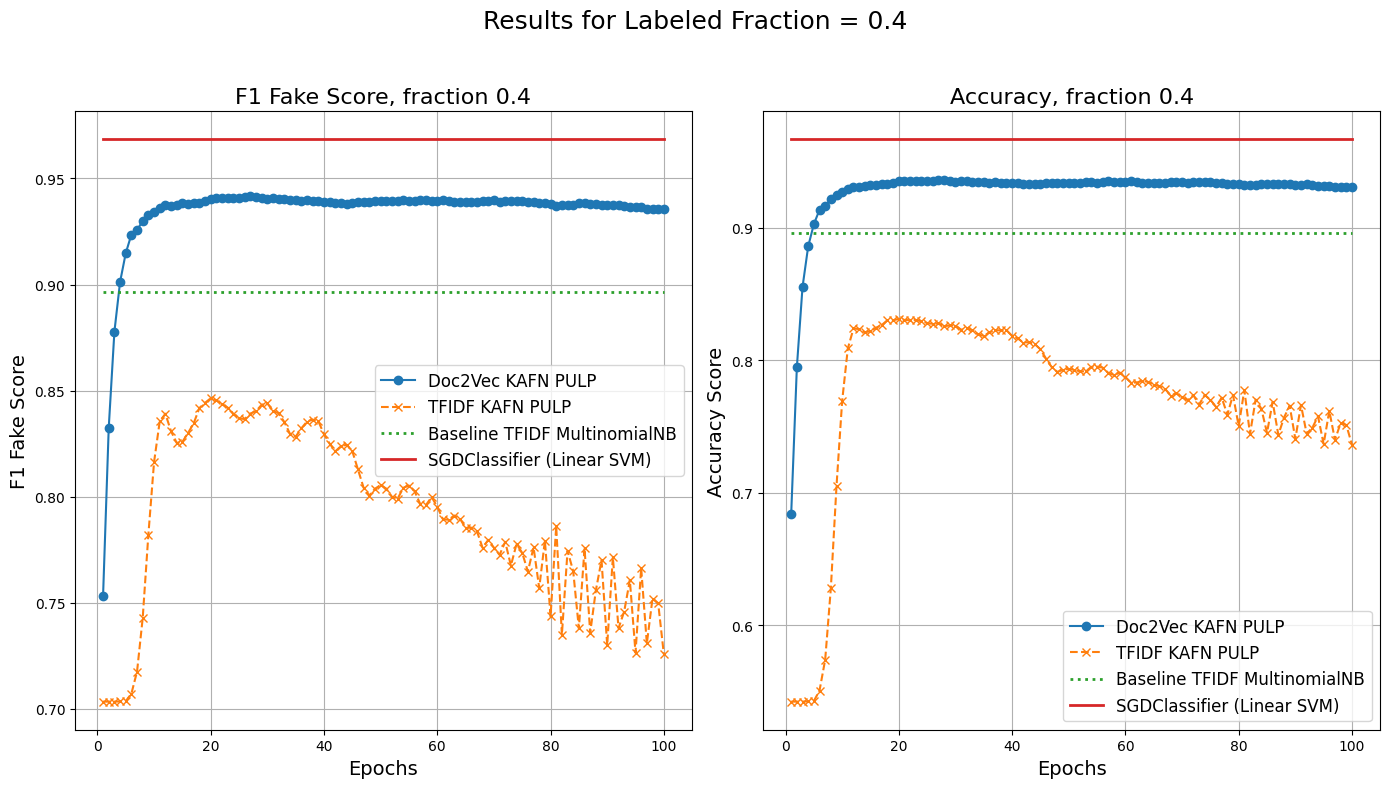

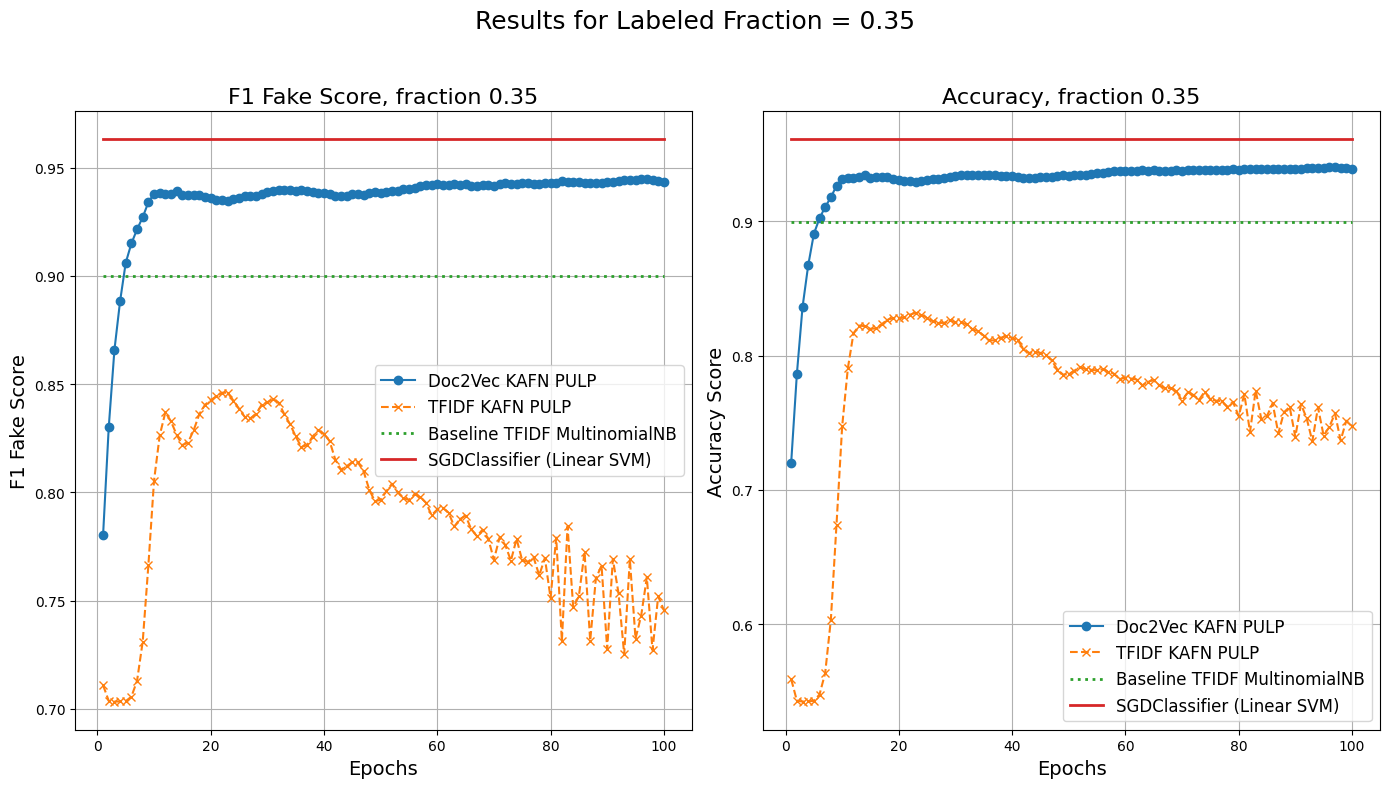

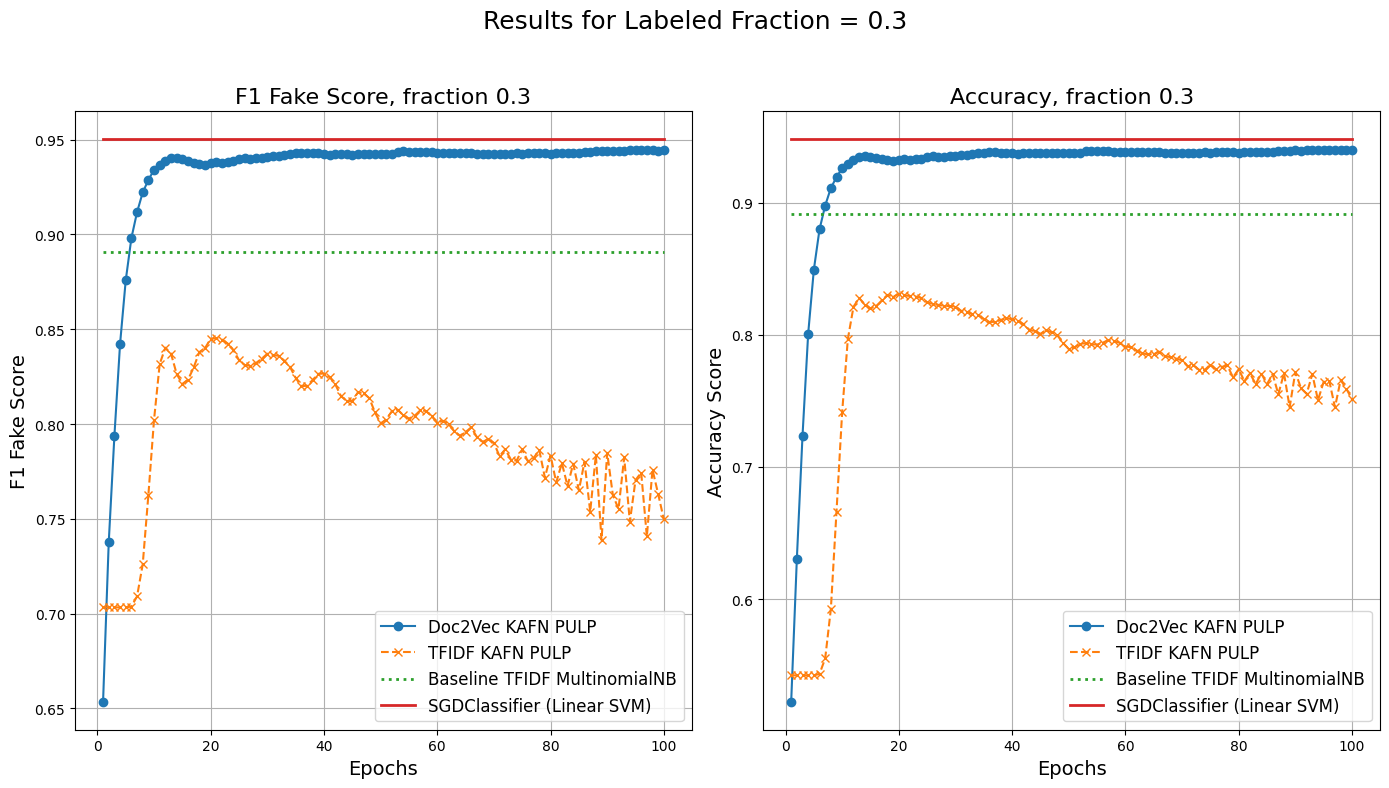

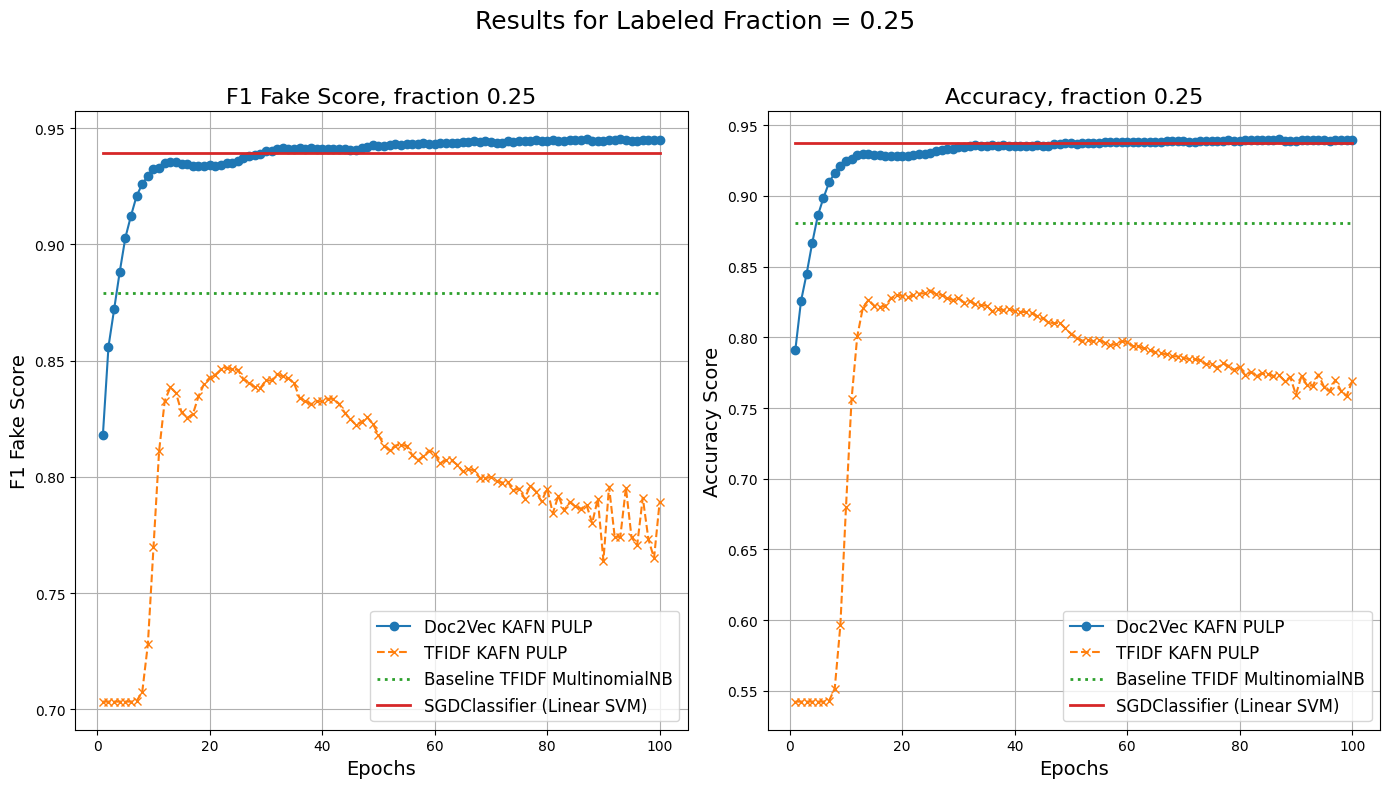

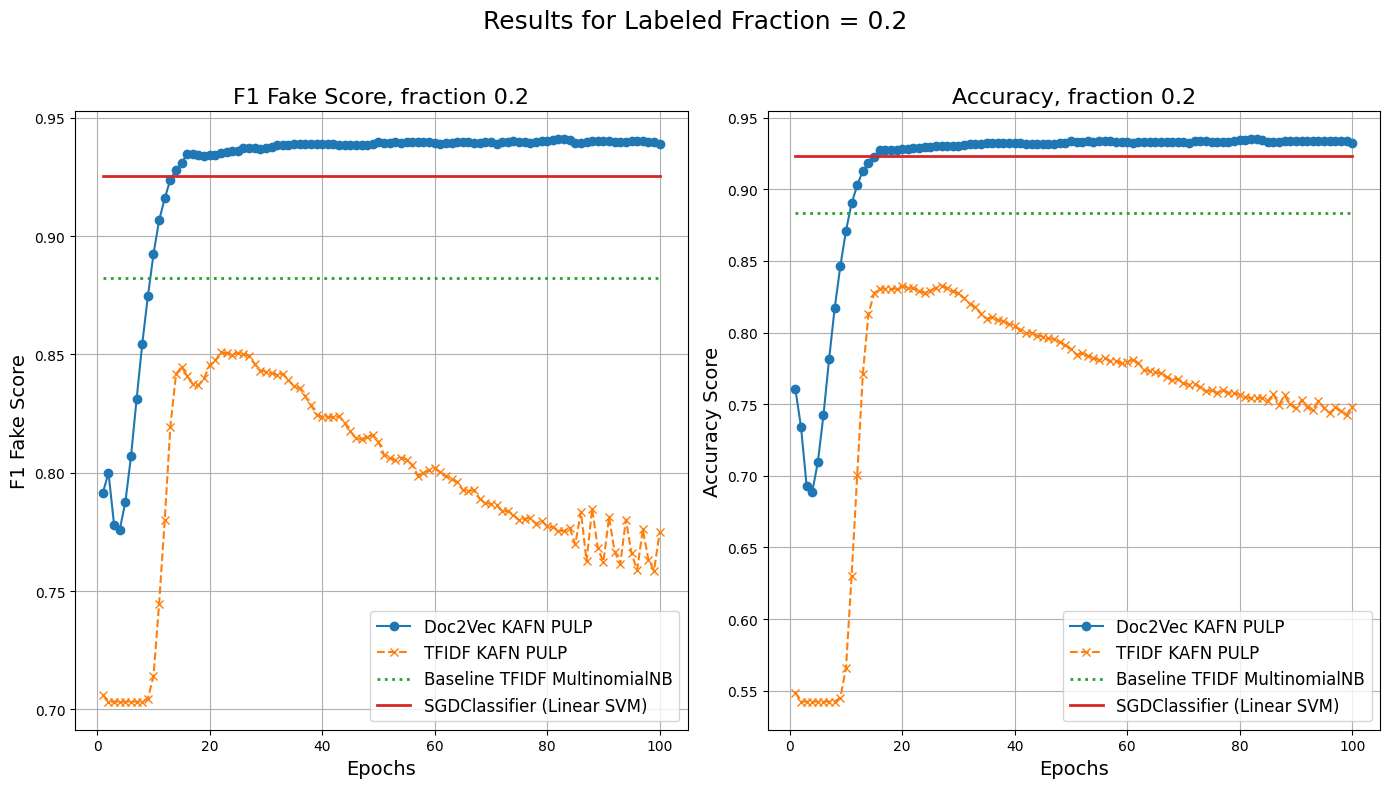

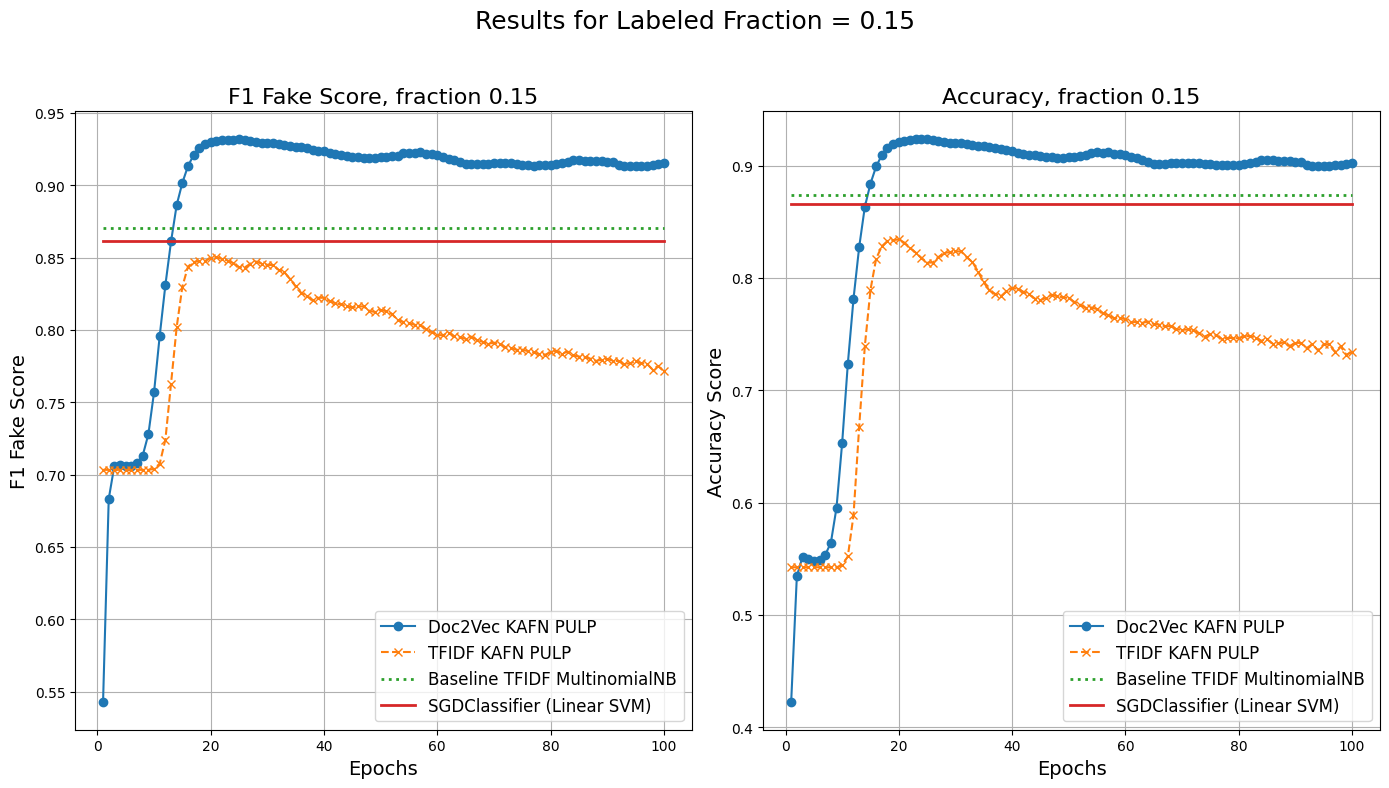

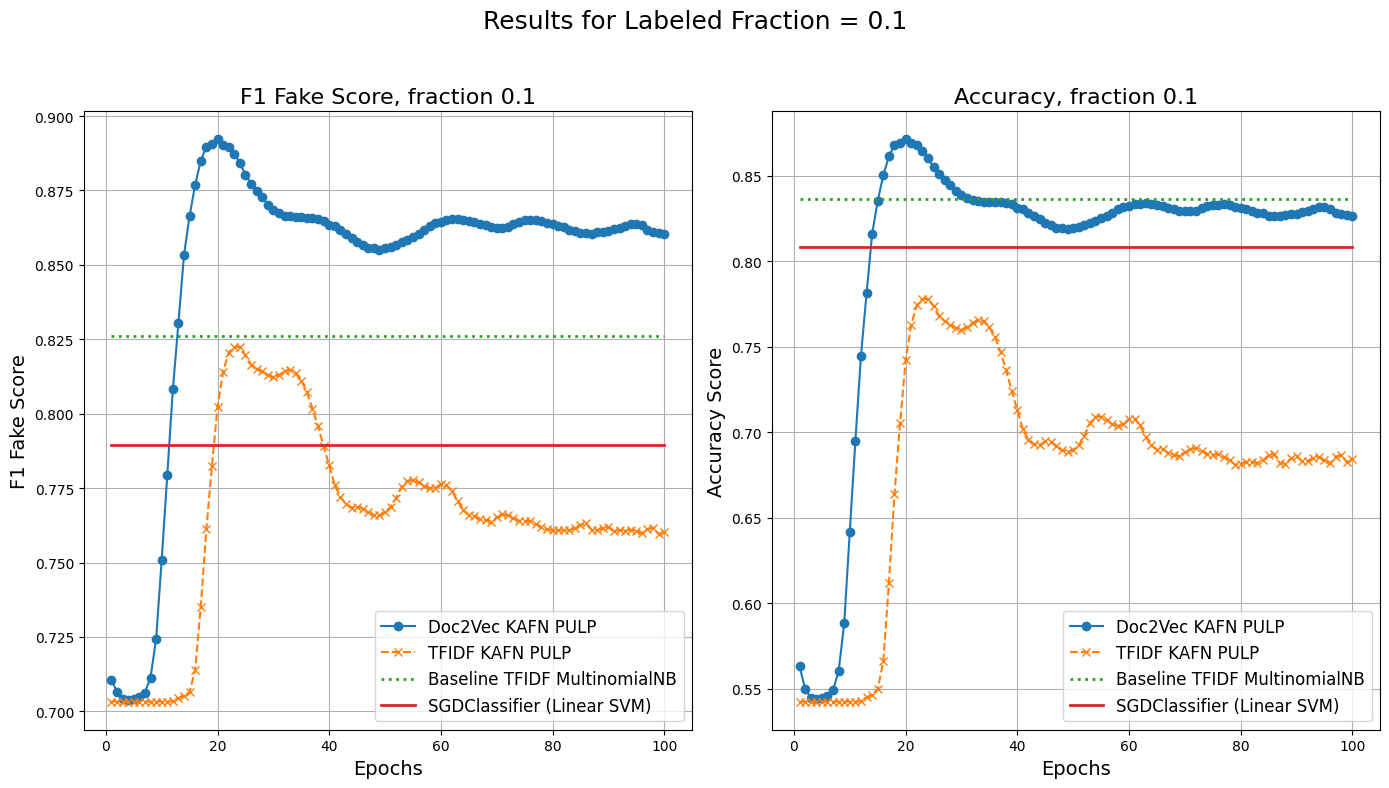

In [38]:
for frac in fraction:
    filename_doc2vec = f"result/kafn_pulp_doc2vec_{frac}.csv"
    filename_tfidf = f"result/kafn_pulp_tfidf_{frac}.csv"
    baseline_file = f"result/baseline_{frac}.csv"
    filename_sgd = f"result/sgd_{frac}.csv"
    df_doc2vec = pd.read_csv(filename_doc2vec)
    df_tfidf = pd.read_csv(filename_tfidf)
    df_baseline = pd.read_csv(baseline_file, index_col=0)
    df_sgd = pd.read_csv(filename_sgd, index_col=0)
    epochs = df_doc2vec["epoch"]
    f1_doc2vec = df_doc2vec["f1_fake"]
    f1_tfidf = df_tfidf["f1_fake"]
    baseline_f1 = df_baseline.loc["fake", "f1-score"]
    sgd_f1 = df_sgd.loc["fake", "f1-score"]
    acc_doc2vec = df_doc2vec["accuracy"]
    acc_tfidf = df_tfidf["accuracy"]
    baseline_acc = df_baseline.loc["accuracy", "f1-score"]
    sgd_acc = df_sgd.loc["accuracy", "f1-score"]
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 8))
    ax1.plot(epochs, f1_doc2vec, marker="o", linestyle="-", label="Doc2Vec KAFN PULP")
    ax1.plot(epochs, f1_tfidf, marker="x", linestyle="--", label="TFIDF KAFN PULP")
    ax1.plot(epochs, [baseline_f1]*len(epochs), linestyle=":", linewidth=2, label="Baseline TFIDF MultinomialNB")
    ax1.plot(epochs, [sgd_f1]*len(epochs), linestyle="-", linewidth=2, label="SGDClassifier (Linear SVM)")
    ax1.set_xlabel("Epochs", fontsize=14)
    ax1.set_ylabel("F1 Fake Score", fontsize=14)
    ax1.set_title(f"F1 Fake Score, fraction {frac}", fontsize=16)
    ax1.grid(True)
    ax1.legend(fontsize=12, loc="best")

    ax2.plot(epochs, acc_doc2vec, marker="o", linestyle="-", label="Doc2Vec KAFN PULP")
    ax2.plot(epochs, acc_tfidf, marker="x", linestyle="--", label="TFIDF KAFN PULP")
    ax2.plot(epochs, [baseline_acc]*len(epochs), linestyle=":", linewidth=2, label="Baseline TFIDF MultinomialNB")
    ax2.plot(epochs, [sgd_acc]*len(epochs), linestyle="-", linewidth=2, label="SGDClassifier (Linear SVM)")
    ax2.set_xlabel("Epochs", fontsize=14)
    ax2.set_ylabel("Accuracy Score", fontsize=14)
    ax2.set_title(f"Accuracy, fraction {frac}", fontsize=16)
    ax2.grid(True)
    ax2.legend(fontsize=12, loc="best")
    
    plt.suptitle(f"Results for Labeled Fraction = {frac}", fontsize=18)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

In [39]:
results = {
    "Doc2Vec KAFN PULP": {},
    "TFIDF KAFN PULP": {},
    "Baseline TFIDF MultinomialNB": {},
    "SGDClassifier (Linear SVM)": {}
}

for frac in fraction:
    df_doc2vec = pd.read_csv(f"result/kafn_pulp_doc2vec_{frac}.csv")
    df_tfidf = pd.read_csv(f"result/kafn_pulp_tfidf_{frac}.csv")
    df_baseline = pd.read_csv(f"result/baseline_{frac}.csv", index_col=0)
    df_sgd = pd.read_csv(f"result/sgd_{frac}.csv", index_col=0)

    max_f1_doc2vec = df_doc2vec["f1_fake"].max()
    max_f1_tfidf = df_tfidf["f1_fake"].max()
    max_acc_doc2vec = df_doc2vec["accuracy"].max()
    max_acc_tfidf = df_tfidf["accuracy"].max()
    baseline_f1 = df_baseline.loc["fake", "f1-score"]
    baseline_acc = df_baseline.loc["accuracy", "f1-score"]
    sgd_f1 = df_sgd.loc["fake", "f1-score"]
    sgd_acc = df_sgd.loc["accuracy", "f1-score"]

    results["Doc2Vec KAFN PULP"][frac] = [max_f1_doc2vec, max_acc_doc2vec]
    results["TFIDF KAFN PULP"][frac] = [max_f1_tfidf, max_acc_tfidf]
    results["Baseline TFIDF MultinomialNB"][frac] = [baseline_f1, baseline_acc]
    results["SGDClassifier (Linear SVM)"][frac] = [sgd_f1, sgd_acc]


new_data = {}
for model, frac_dict in results.items():
    row_data = {}
    for frac, metrics_list in frac_dict.items():
        row_data[(str(frac), "F-1")] = metrics_list[0]
        row_data[(str(frac), "Accuracy")] = metrics_list[1]
    new_data[model] = row_data

df_results = pd.DataFrame.from_dict(new_data, orient="index")
columns = pd.MultiIndex.from_product(
    ([str(frac) for frac in fraction], ["F-1", "Accuracy"]),
    names=["Fraction", "Metric"],
)
df_results = df_results[columns]
styled_df = df_results.style.highlight_max(
    axis=0, props="background-color: green; font-weight: bold;"
)

styled_df

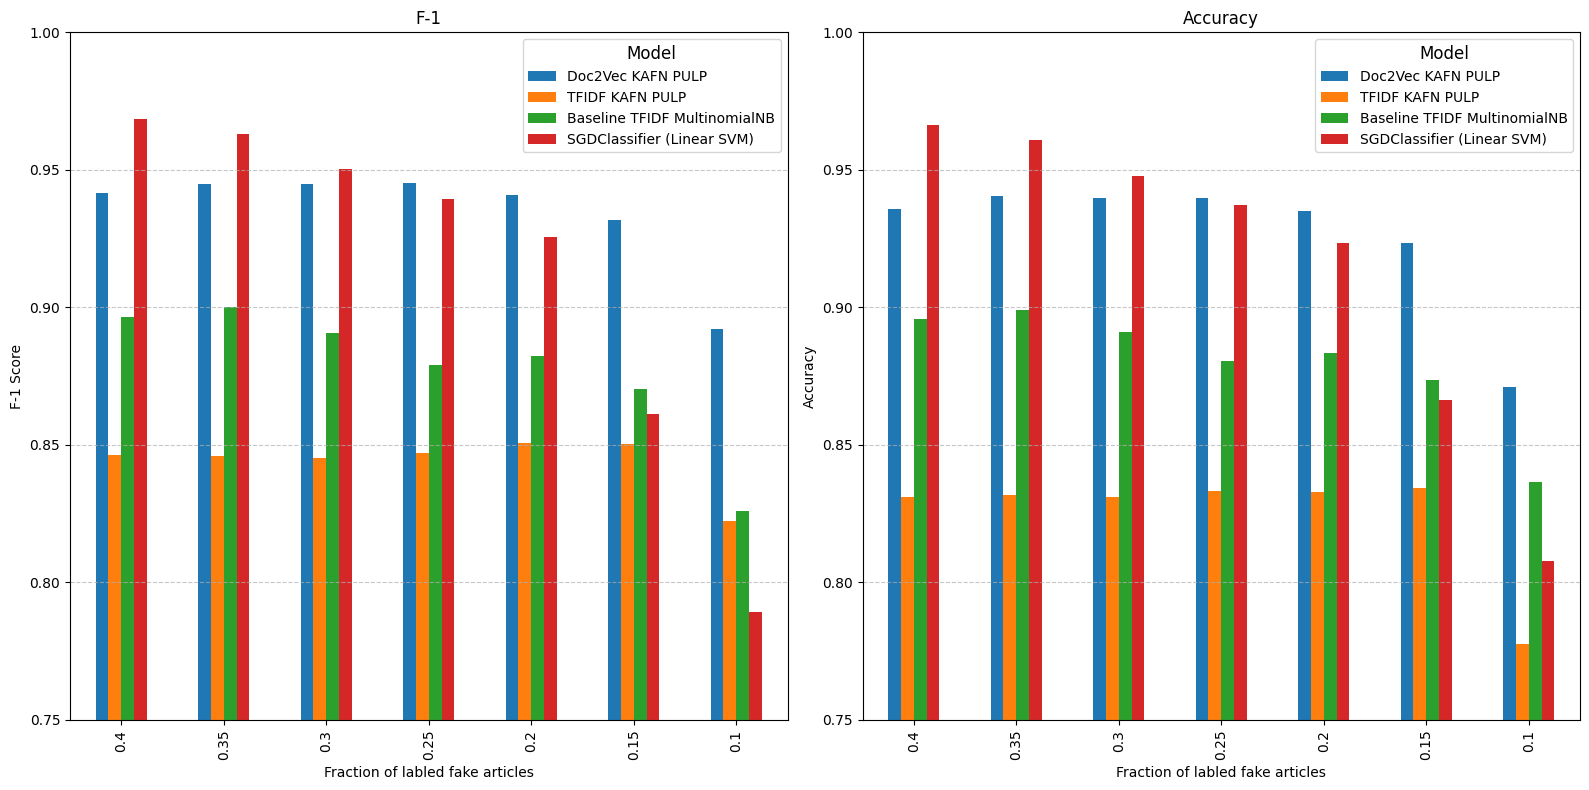

In [40]:
df_results.columns = pd.MultiIndex.from_tuples(df_results.columns, names=["Fraction", "Metric"])
df_f1 = df_results.xs("F-1", axis=1, level="Metric")
df_acc = df_results.xs("Accuracy", axis=1, level="Metric")
df_f1_T = df_f1.T
df_acc_T = df_acc.T
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 8), sharey=False)

# Plot F-1 Score
df_f1_T.plot(kind="bar", ax=axes[0])
axes[0].set_title("F-1")
axes[0].set_xlabel("Fraction of labled fake articles")
axes[0].set_ylabel("F-1 Score")
axes[0].set_ylim(0.75, 1.0)
axes[0].legend(title="Model", fontsize=10, title_fontsize=12)
axes[0].grid(True, axis="y", linestyle="--", alpha=0.7)

# Plot Accuracy
df_acc_T.plot(kind="bar", ax=axes[1])
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Fraction of labled fake articles")
axes[1].set_ylabel("Accuracy")
axes[1].set_ylim(0.75, 1.0)
axes[1].legend(title="Model", fontsize=10, title_fontsize=12)
axes[1].grid(True, axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()

### 7.2 Results Evaluation

## 8. Conclusion

## 9. Backend app

In [47]:
from flask import Flask, request, jsonify

app = Flask(__name__ )


@app.route('/')
def home():
    return jsonify({"home": "works"}), 200


@app.route('/predict',methods=['POST'])
def predict():
    content = request.json
    if not content or "text" not in content:
        return jsonify({"error": "No text provided"}), 400
    
    
    return jsonify({"test result": "great success"}), 200
        
     


if __name__ == "__main__":
    app.run(host="0.0.0.0", port=5555, debug=False)

 * Serving Flask app '__main__'
 * Debug mode: off


 * Running on all addresses (0.0.0.0)
 * Running on http://127.0.0.1:5555
 * Running on http://192.168.1.7:5555
Press CTRL+C to quit
127.0.0.1 - - [12/Feb/2025 07:41:53] "POST /predict HTTP/1.1" 200 -
